In [2]:
 !pip install 'keras<3.0.0' mediapipe-model-maker

In [3]:
import tensorflow as tf
import gc
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout, GlobalAveragePooling2D, Activation, BatchNormalization, Dropout, LSTM, ConvLSTM2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Input,Conv2D, SeparableConv2D, MaxPool2D, LeakyReLU, Activation, LSTM, ConvLSTM2D, Lambda, Reshape, BatchNormalization, Bidirectional
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint,TensorBoard,TerminateOnNaN, LearningRateScheduler, CSVLogger
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.layers import Lambda, Reshape, DepthwiseConv2D, ZeroPadding2D, Add, MaxPooling2D,Activation, Flatten, Conv2D, Dense, Input, Dropout, Concatenate, GlobalMaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from tensorflow.keras import preprocessing
from keras.applications import imagenet_utils
from tensorflow.keras import layers
!pip install tensorflow-addons==0.23.0

import tensorflow_addons as tfa
import pandas as pd
import numpy as np
import random
import keras
import shutil
import pathlib
import itertools
import cv2
import os
import matplotlib.image as mpimg
import seaborn as sns
import os
import cv2
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras 
from keras.callbacks import EarlyStopping,ModelCheckpoint
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

2024-09-18 09:25:00.866464: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-18 09:25:00.866529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-18 09:25:00.869011: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [4]:
!pip install tensorflow-addons
# import tensorflow_addons as tfa

In [5]:
import tensorflow_addons as tfa

In [6]:
def DataFrame(path):
    images = []
    labels = []
    for subfolder in os.listdir(path):
        subfolder_path = os.path.join(path, subfolder)
        if not os.path.isdir(subfolder_path):
            continue
        for image_filename in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, image_filename)
            images.append(image_path)
            labels.append(subfolder)
    df = pd.DataFrame({'image': images, 'label': labels})
    return df
train_df=DataFrame('/kaggle/input/brain-tumor-mri-dataset/Training')
train_df

,image,label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [7]:
test_df=DataFrame('/kaggle/input/brain-tumor-mri-dataset/Testing')
test_df

,image,label
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1306,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1307,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1308,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1309,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


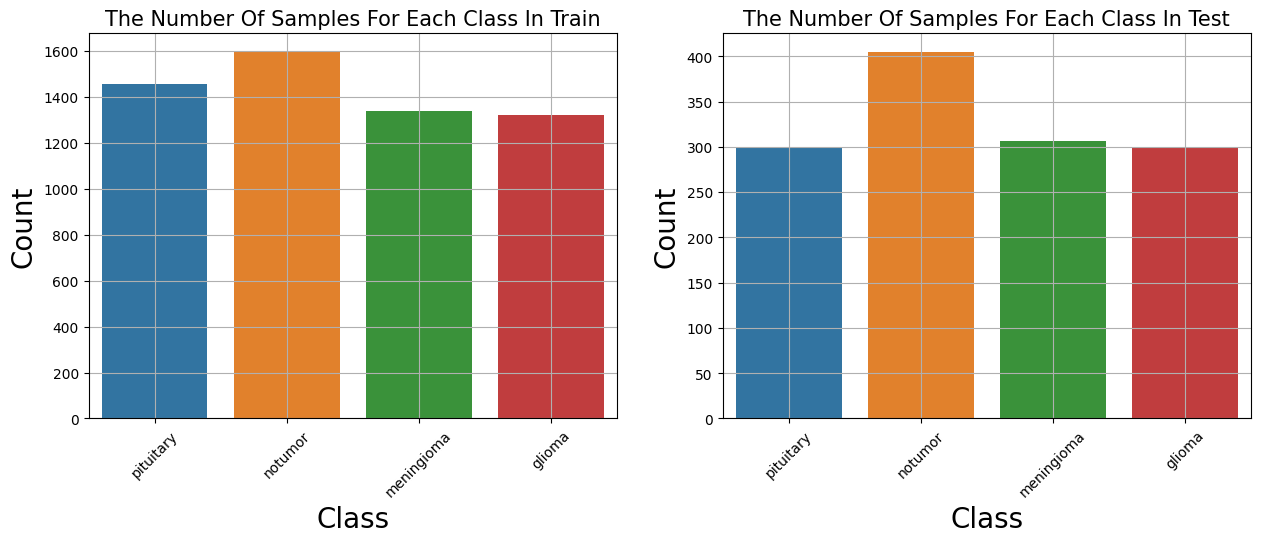

In [8]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.countplot(x=train_df.label)
plt.xlabel("Class",fontsize=20)
plt.title("The Number Of Samples For Each Class In Train",fontsize=15)
plt.ylabel('Count',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.subplot(1,2,2)
sns.countplot(x=test_df.label)
plt.xlabel("Class",fontsize=20)
plt.title("The Number Of Samples For Each Class In Test",fontsize=15)
plt.ylabel('Count',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


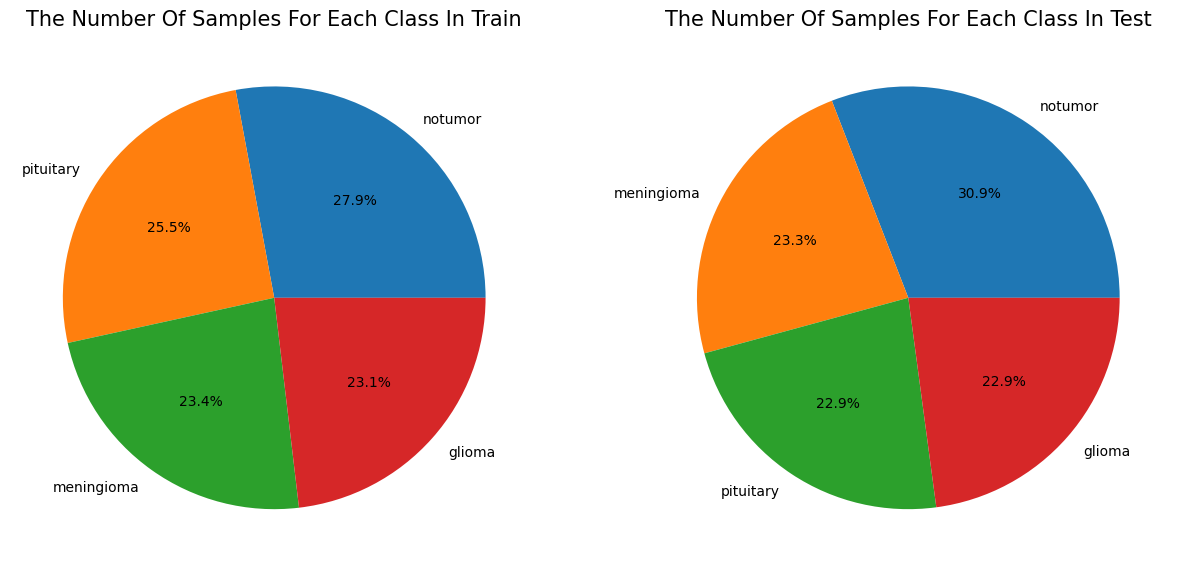

In [9]:
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.pie(train_df.label.value_counts(),labels=train_df.label.value_counts().index,autopct ='%1.1f%%')
plt.title("The Number Of Samples For Each Class In Train",fontsize=15)
plt.subplot(1,2,2)
plt.pie(test_df.label.value_counts(),labels=test_df.label.value_counts().index,autopct ='%1.1f%%')
plt.title("The Number Of Samples For Each Class In Test",fontsize=15)
plt.show()

In [10]:
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_dir = '/kaggle/input/brain-tumor-mri-dataset/Testing'

In [11]:
for dirpath, dirnames, filenames in os.walk(train_dir):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 4 directories and 0 images in '/kaggle/input/brain-tumor-mri-dataset/Training'.
There are 0 directories and 1457 images in '/kaggle/input/brain-tumor-mri-dataset/Training/pituitary'.
There are 0 directories and 1595 images in '/kaggle/input/brain-tumor-mri-dataset/Training/notumor'.
There are 0 directories and 1339 images in '/kaggle/input/brain-tumor-mri-dataset/Training/meningioma'.
There are 0 directories and 1321 images in '/kaggle/input/brain-tumor-mri-dataset/Training/glioma'.


In [12]:
for dirpath, dirnames, filenames in os.walk(test_dir):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 4 directories and 0 images in '/kaggle/input/brain-tumor-mri-dataset/Testing'.
There are 0 directories and 300 images in '/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary'.
There are 0 directories and 405 images in '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor'.
There are 0 directories and 306 images in '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma'.
There are 0 directories and 300 images in '/kaggle/input/brain-tumor-mri-dataset/Testing/glioma'.


In [13]:
EPOCHS = 50
from math import floor
N_FOLDS = 5
INIT_LR = 1e-3
T_BS = 16
V_BS = 16
decay_rate = 0.95
decay_step = 1
IMAGE_SIZE = [224,224]

In [14]:
import tensorflow_addons as tfa

def augment_image(image, label):
    # Apply augmentation transformations
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.1)

    # Apply the width and height shifts
    width_shift = tf.random.uniform([], -0.2, 0.2) * tf.cast(tf.shape(image)[1], tf.float32)
    height_shift = tf.random.uniform([], -0.2, 0.2) * tf.cast(tf.shape(image)[0], tf.float32)
    image = tfa.image.translate(image, [width_shift, height_shift])

    return image, label

In [15]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode="categorical",
                                                                 batch_size=32,
                                                                 image_size=IMAGE_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMAGE_SIZE,
                                                                shuffle=False)

Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


In [16]:
class_names =train_data.class_names
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

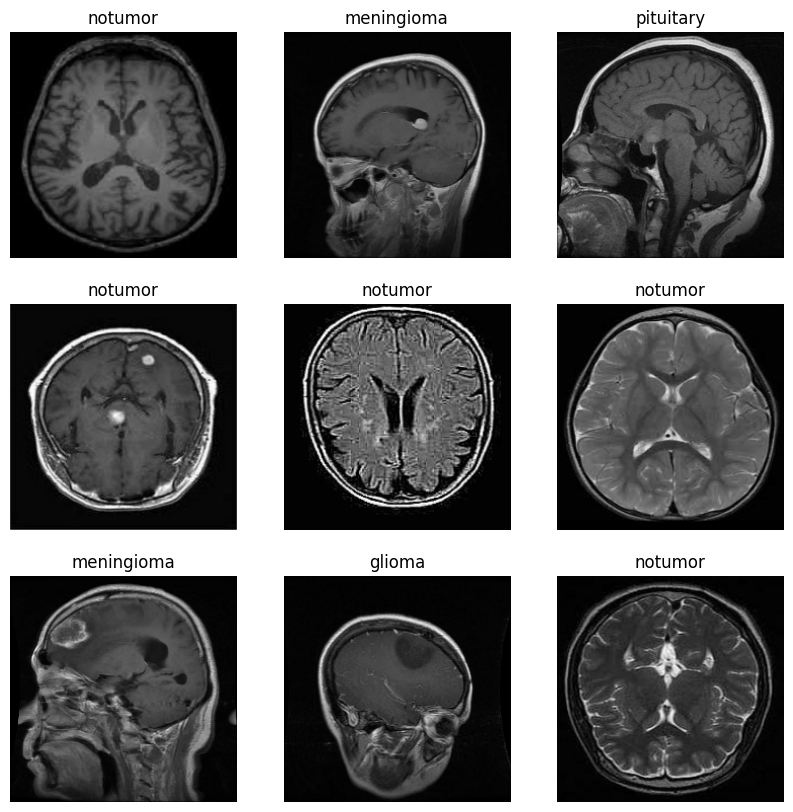

In [17]:
import matplotlib.pyplot as plt

# Extract a batch of images and labels from the train_data dataset
for images, labels in train_data.take(1):
    # Display the first 9 images from the batch
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i])])  # Assuming class_names is a list containing the class names
        plt.axis("off")
    plt.show()


In [18]:
# Apply augmentation to the training dataset using the map function
# train_dataset_augmented = train_data.map(augment_image)
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

train_dataset_preprocessed = train_data.map(preprocess_image)
train_dataset_augmented = train_dataset_preprocessed.map(augment_image)


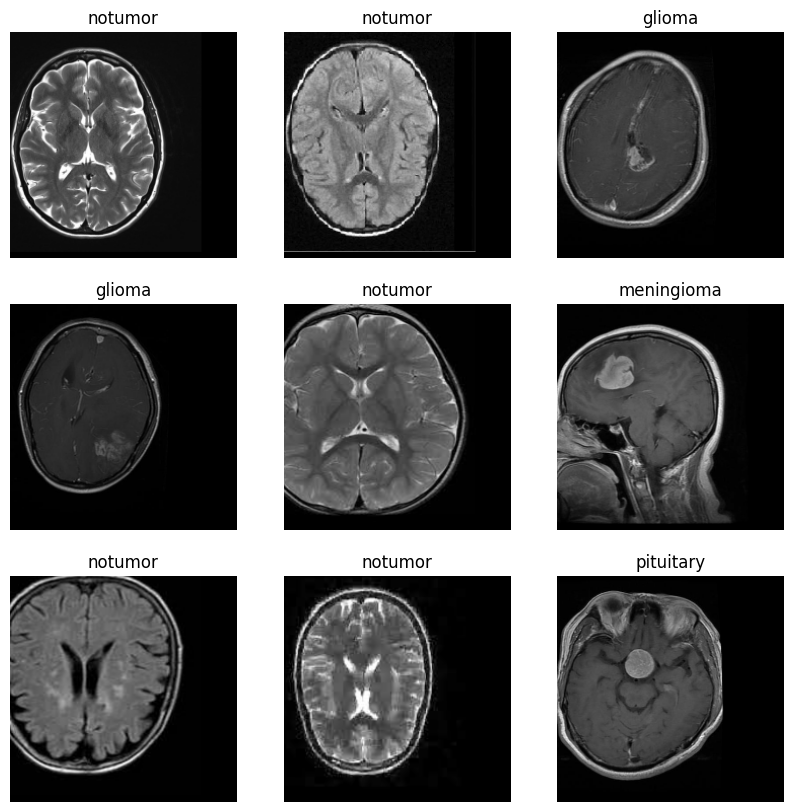

In [19]:
import matplotlib.pyplot as plt

# Define a function to plot augmented images
def plot_augmented_images(dataset, num_samples=5):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):  # Take one batch of augmented images
        for i in range(num_samples):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[tf.argmax(labels[i])])  # Assuming class_names is defined
            plt.axis("off")
    plt.show()

# Plot some augmented images
plot_augmented_images(train_dataset_augmented, num_samples=9)

In [20]:
from tensorflow.keras.layers import Lambda
import tensorflow as tf
def Combined_model():
    # Input layer
    input_layer = Input(shape=(224, 224, 3))

    # Base VGG19 model as a feature extractor
    baseModel = VGG19(weights=None, include_top=False, input_tensor=input_layer)

    # Load the weights from the local file (specify the path)
    baseModel.load_weights('/kaggle/input/weight321/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5')

    # Freeze the layers of the VGG19 model
    for layer in baseModel.layers:
        layer.trainable = False

    x = baseModel.output


    
    # LSTM layer
    x = Reshape((49, 512))(x)
    x = LSTM(512, activation="relu", return_sequences=True, trainable=False)(x)
    x = BatchNormalization()(x)

    # FC layer
    x = Flatten(name="flatten")(x)

    # fc1 layer
    x = Dense(units=4096, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # fc2 layer
    x = Dense(units=4096, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    # Output layer
    output = Dense(units=4, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output)
    opt = Adam(lr=1e-3)
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=["accuracy"])

    return model

# Create the model
model = Combined_model()

# Print the model summary
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

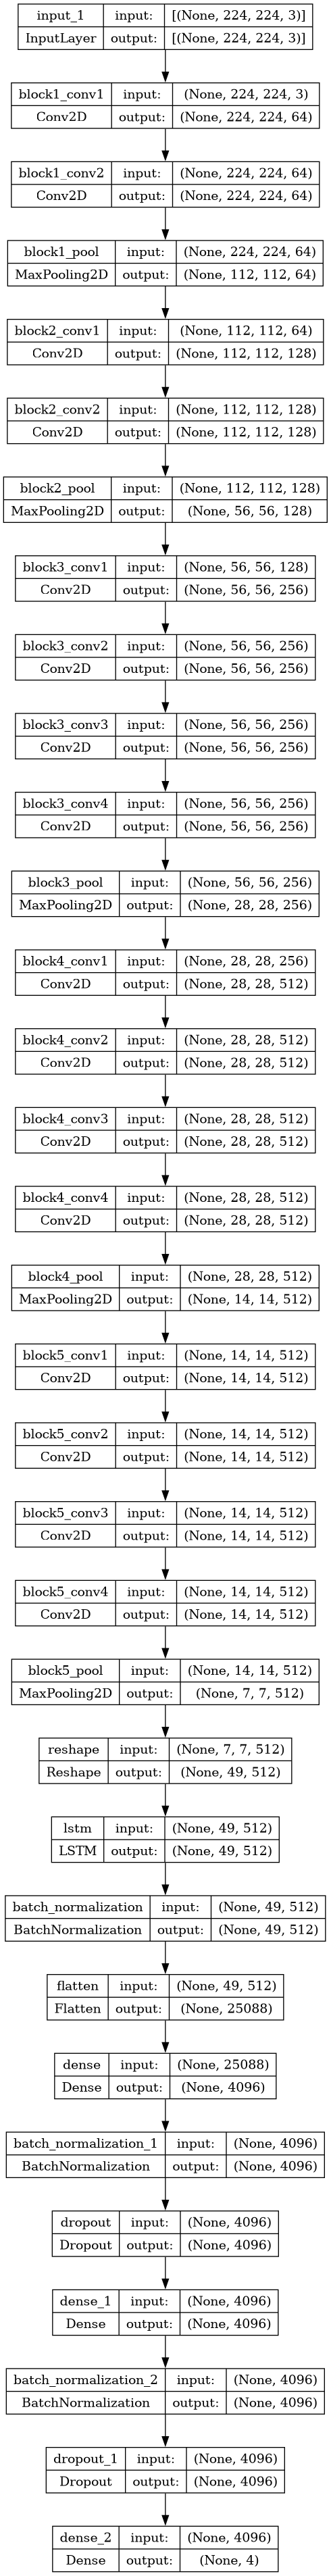

In [21]:
from tensorflow.keras.utils import plot_model

# Visualize the model
plot_model(model, to_file='combined_model.png', show_shapes=True, show_layer_names=True)

In [22]:
checkpoint = [ModelCheckpoint(filepath='best_model.h5', monitor='val_accuracy',mode='max',verbose=1,save_best_only=True,save_weights_only=True),
             LearningRateScheduler(lambda epoch : INIT_LR * pow(decay_rate, floor(epoch / decay_step)))]
earlystop = EarlyStopping(monitor='accuracy', min_delta=0, patience=15, verbose=1, mode='max')

In [23]:
history = model.fit(train_dataset_augmented,
                    epochs=50,
                    steps_per_epoch=len(train_dataset_augmented),
                    validation_data = test_data,
                    callbacks=[checkpoint])

Epoch 1/50


I0000 00:00:1726651553.614006    1600 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 [==============================] - ETA: 0s - loss: 1.2190 - accuracy: 0.7691
Epoch 1: val_accuracy improved from -inf to 0.81998, saving model to best_model.h5
179/179 [==============================] - 70s 321ms/step - loss: 1.2190 - accuracy: 0.7691 - val_loss: 1.2426 - val_accuracy: 0.8200 - lr: 0.0010
Epoch 2/50
179/179 [==============================] - ETA: 0s - loss: 0.6251 - accuracy: 0.8298
Epoch 2: val_accuracy improved from 0.81998 to 0.85431, saving model to best_model.h5
179/179 [==============================] - 46s 252ms/step - loss: 0.6251 - accuracy: 0.8298 - val_loss: 0.8219 - val_accuracy: 0.8543 - lr: 9.5000e-04
Epoch 3/50
179/179 [==============================] - ETA: 0s - loss: 0.5061 - accuracy: 0.8514
Epoch 3: val_accuracy improved from 0.85431 to 0.86957, saving model to best_model.h5
179/179 [==============================] - 46s 255ms/step - loss: 0.5061 - accuracy: 0.8514 - val_loss: 0.6457 - val_accuracy: 0.8696 - lr: 9.0250e-04
Epoch 4/50
179/179 

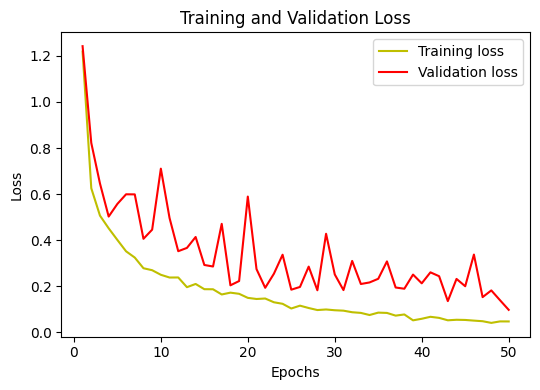

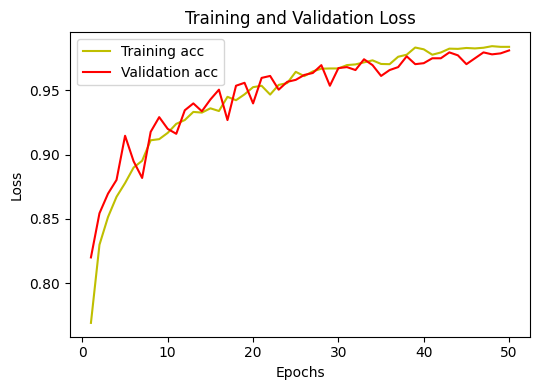

In [24]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(5.5, 4))

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss', fontsize=12)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(False)

plt.tight_layout()
plt.show()

loss = history.history['accuracy']
val_loss = history.history['val_accuracy']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(5.5, 4))

plt.plot(epochs, loss, 'y', label='Training acc')
plt.plot(epochs, val_loss, 'r', label='Validation acc')
plt.title('Training and Validation Loss', fontsize=12)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(fontsize=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(False)

plt.tight_layout()
plt.show()

In [25]:

_, accuracy = model.evaluate(test_data)
print(f"Test accuracy: {round(accuracy * 100, 2)}%")

41/41 [==============================] - 7s 167ms/step - loss: 0.0966 - accuracy: 0.9809
Test accuracy: 98.09%


In [26]:
pred_probs = model.predict(test_data, verbose=1)

41/41 [==============================] - 7s 166ms/step


In [27]:
pred_classes = pred_probs.argmax(axis=1)

y_labels = []
for images, labels in test_data.unbatch():
  y_labels.append(labels.numpy().argmax())

In [28]:
target_names = ['Glioma', 'Meningioma', 'No Tumor','Pituitary']
print(classification_report(y_labels,
                            pred_classes,
                            target_names=target_names, digits=4))

              precision    recall  f1-score   support

      Glioma     0.9826    0.9400    0.9608       300
  Meningioma     0.9408    0.9869    0.9633       306
    No Tumor     1.0000    0.9951    0.9975       405
   Pituitary     0.9967    0.9967    0.9967       300

    accuracy                         0.9809      1311
   macro avg     0.9800    0.9797    0.9796      1311
weighted avg     0.9814    0.9809    0.9809      1311



In [29]:
cm = confusion_matrix(y_labels,pred_classes)

TP = cm[0, 0]
TN = cm[1:, 1:].sum()
FP = cm[0, 1:].sum()
FN = cm[1:, 0].sum()

Population = TN+FN+TP+FP
spesificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)

print("True Positives:", TP)
print("False Positives:", FP)
print("True Negatives:", TN)
print("False Negatives:", FN)
print("Specificity:", spesificity)
print("Sensitivity:", sensitivity)

True Positives: 282
False Positives: 18
True Negatives: 1006
False Negatives: 5
Specificity: 0.982421875
Sensitivity: 0.9825783972125436


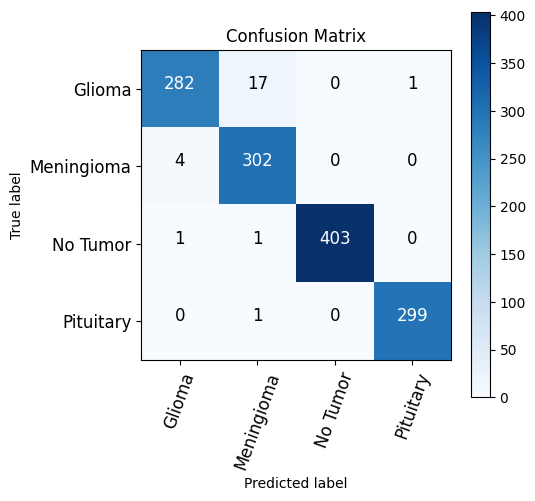

In [30]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(20, 20), text_size=15, norm=False, savefig=False):

  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
  n_classes = cm.shape[0]

  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues)
  fig.colorbar(cax)

  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  ax.grid(False)

  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes),
         yticks=np.arange(n_classes),
         xticklabels=labels,
         yticklabels=labels)

  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  threshold = (cm.max() + cm.min()) / 2.

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)


make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=target_names,
                      figsize=(5, 5),
                      text_size=12,
                      norm=False,
                      savefig=True)

In [31]:
model.save("model.h5")

1/1 [==============================] - 0s 288ms/step


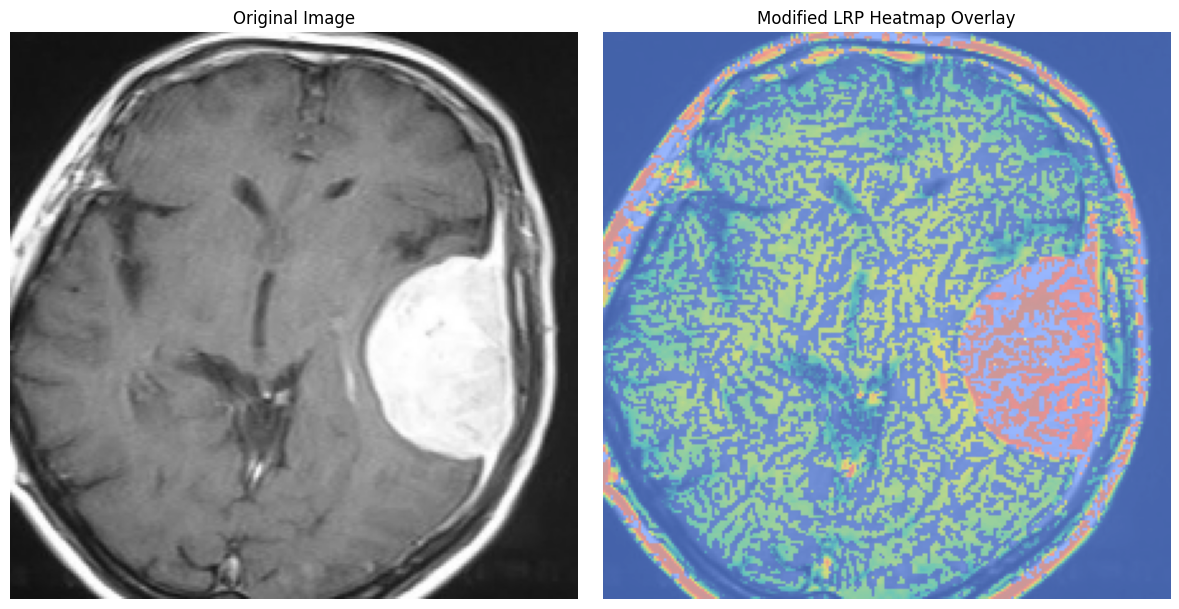

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Layer

class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0012.jpg'
sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, (224, 224))
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Load the VGG16 model and stop at block5_conv3
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
layer_name = 'block5_conv3'
model = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)

# Add global pooling and a linear dense layer
x = GlobalAveragePooling2D()(model.output)
output = Dense(1000, activation='linear')(x)
final_model = Model(inputs=model.input, outputs=output)

# Create the LRP model using the modified layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(sample_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]

# Clip values to enhance focus
lrp_result = np.clip(lrp_result, 0.2, 1)

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(sample_image[0], cmap='gray')
plt.title("Original Image")
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Only use the first 2D slice of LRP result
plt.imshow(sample_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title("Modified LRP Heatmap Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 293ms/step


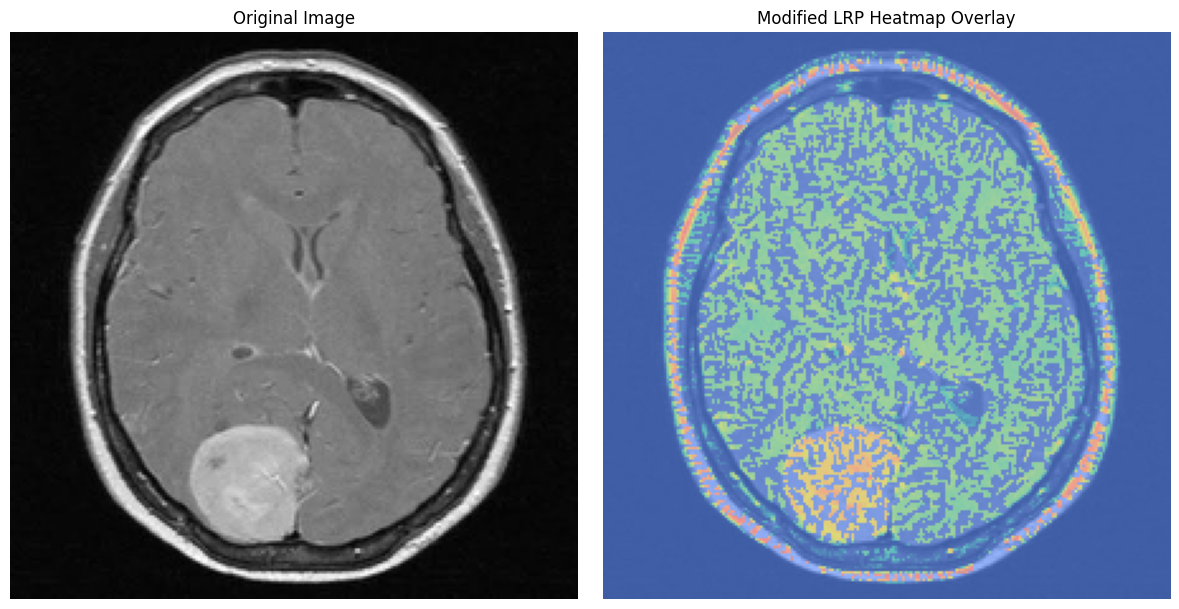

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Layer

class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0010.jpg'
sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, (224, 224))
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Load the VGG16 model and stop at block5_conv3
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
layer_name = 'block5_conv3'
model = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)

# Add global pooling and a linear dense layer
x = GlobalAveragePooling2D()(model.output)
output = Dense(1000, activation='linear')(x)
final_model = Model(inputs=model.input, outputs=output)

# Create the LRP model using the modified layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(sample_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]

# Clip values to enhance focus
lrp_result = np.clip(lrp_result, 0.2, 1)

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(sample_image[0], cmap='gray')
plt.title("Original Image")
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Only use the first 2D slice of LRP result
plt.imshow(sample_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title("Modified LRP Heatmap Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 293ms/step


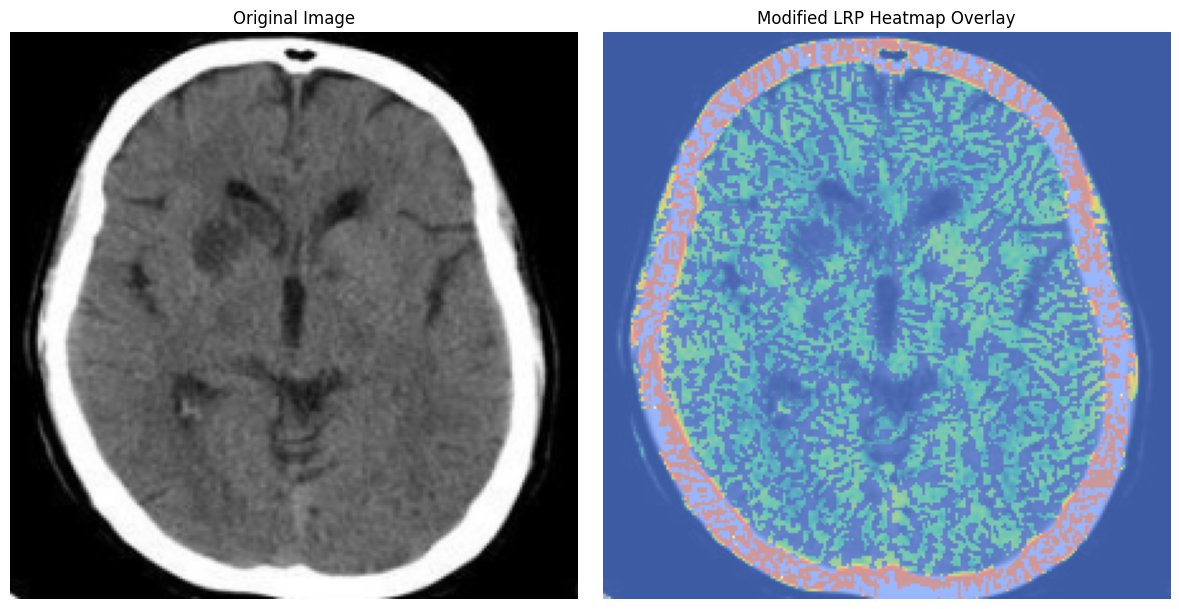

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Layer

class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_0010.jpg'
sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, (224, 224))
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Load the VGG16 model and stop at block5_conv3
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
layer_name = 'block5_conv3'
model = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)

# Add global pooling and a linear dense layer
x = GlobalAveragePooling2D()(model.output)
output = Dense(1000, activation='linear')(x)
final_model = Model(inputs=model.input, outputs=output)

# Create the LRP model using the modified layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(sample_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]

# Clip values to enhance focus
lrp_result = np.clip(lrp_result, 0.2, 1)

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(sample_image[0], cmap='gray')
plt.title("Original Image")
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Only use the first 2D slice of LRP result
plt.imshow(sample_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title("Modified LRP Heatmap Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 311ms/step
Original Image Name: Te-me_0010.jpg
Predicted Class Name: Meningioma
1/1 [==============================] - 1s 894ms/step


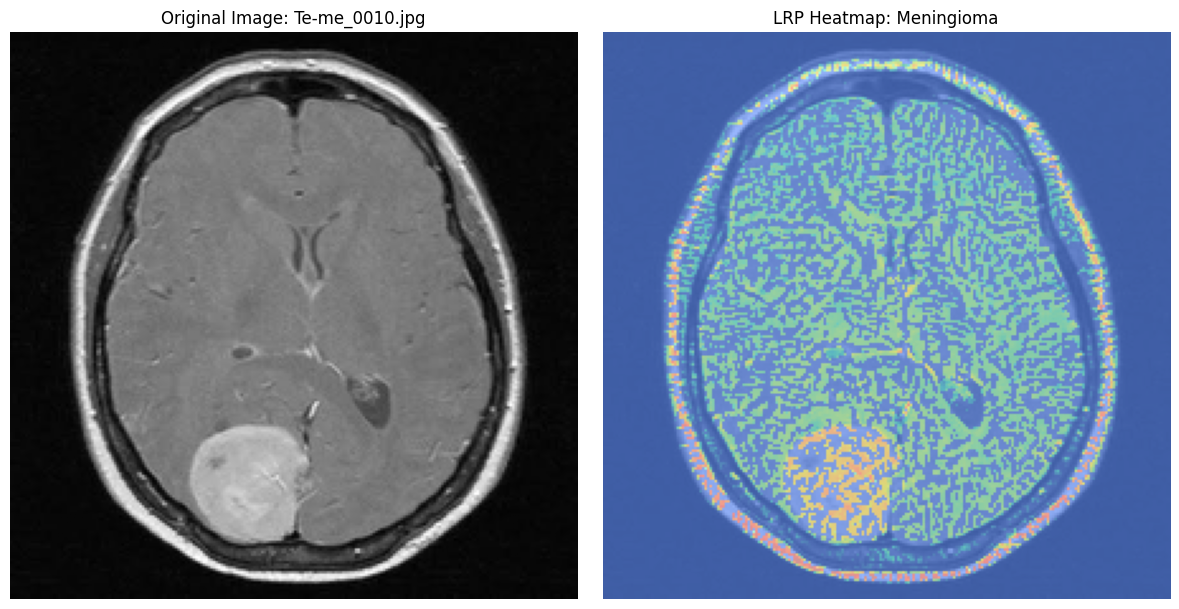

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0010.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, (224, 224))
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image
prediction = final_model.predict(sample_image)
predicted_class = np.argmax(prediction, axis=1)[0]

# Map predicted class index to actual class names
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
predicted_class_name = class_names[predicted_class]

# Print the original image name and the predicted class name
print(f"Original Image Name: {image_name}")
print(f"Predicted Class Name: {predicted_class_name}")

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(sample_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(sample_image[0])
plt.title(f"Original Image: {image_name}")
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(sample_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap: {predicted_class_name}")
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 312ms/step
Original Image Name: Te-noTr_0001.jpg
Predicted Class Name: No Tumor
1/1 [==============================] - 1s 883ms/step


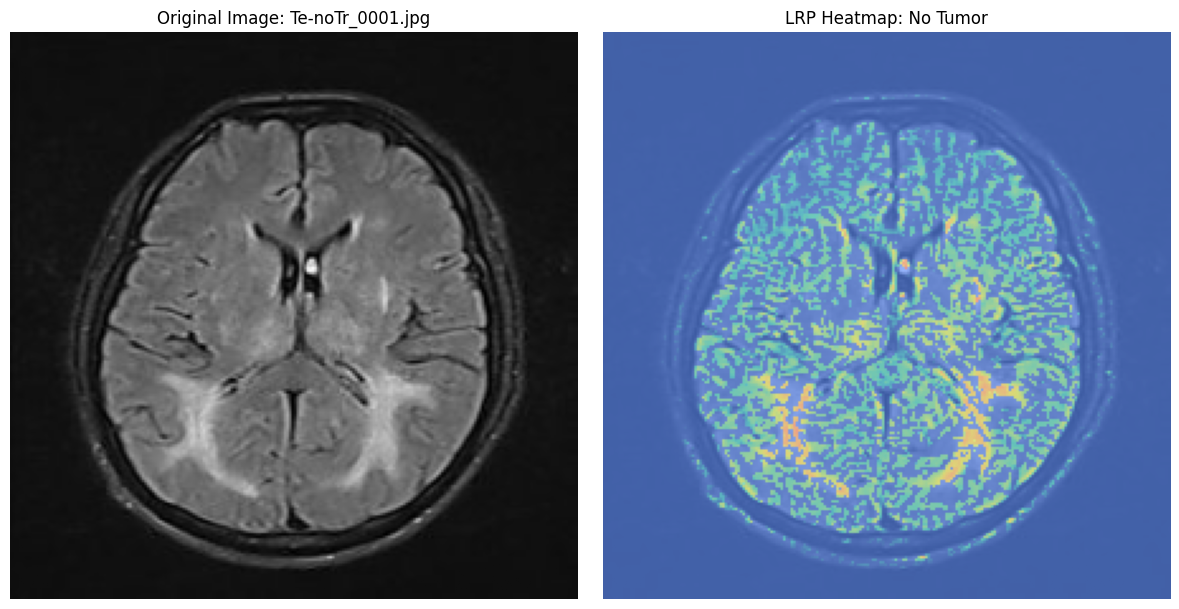

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-noTr_0001.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, (224, 224))
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image
prediction = final_model.predict(sample_image)
predicted_class = np.argmax(prediction, axis=1)[0]

# Map predicted class index to actual class names
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
predicted_class_name = class_names[predicted_class]

# Print the original image name and the predicted class name
print(f"Original Image Name: {image_name}")
print(f"Predicted Class Name: {predicted_class_name}")

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(sample_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(sample_image[0])
plt.title(f"Original Image: {image_name}")
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(sample_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap: {predicted_class_name}")
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 301ms/step
Original Image Name: Te-me_0010.jpg
1/1 [==============================] - 1s 908ms/step


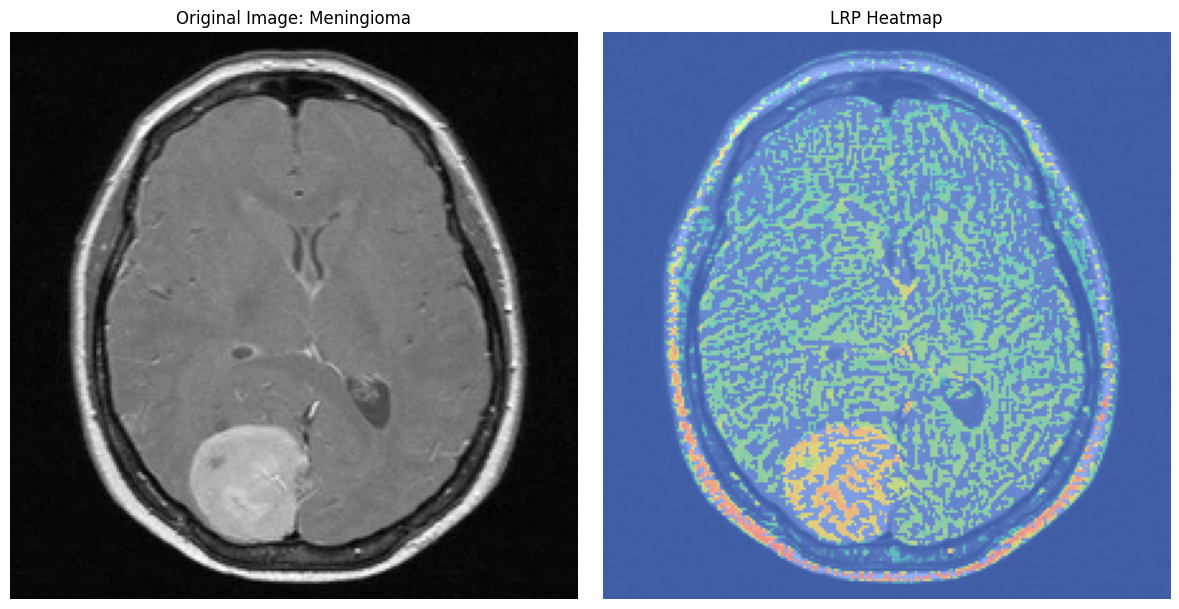

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Preprocessing function
IMAGE_SIZE = (224, 224)
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0010.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, IMAGE_SIZE)
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image using correct preprocessing
preprocessed_image = preprocess_image(sample_image, None)[0]  # Preprocess using your defined method
prediction = final_model.predict(preprocessed_image)
predicted_class = np.argmax(prediction, axis=1)[0]

# Map predicted class index to actual class names
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
original_class_name = class_names[predicted_class]  # This will be the original class name

# Print the original image name (no predicted class)
print(f"Original Image Name: {image_name}")

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(preprocessed_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(preprocessed_image[0])
plt.title(f"Original Image: {original_class_name}")  # Display only the class name
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(preprocessed_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap")  # No class name here
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 315ms/step
Original Image Name: Te-noTr_0001.jpg
1/1 [==============================] - 1s 878ms/step


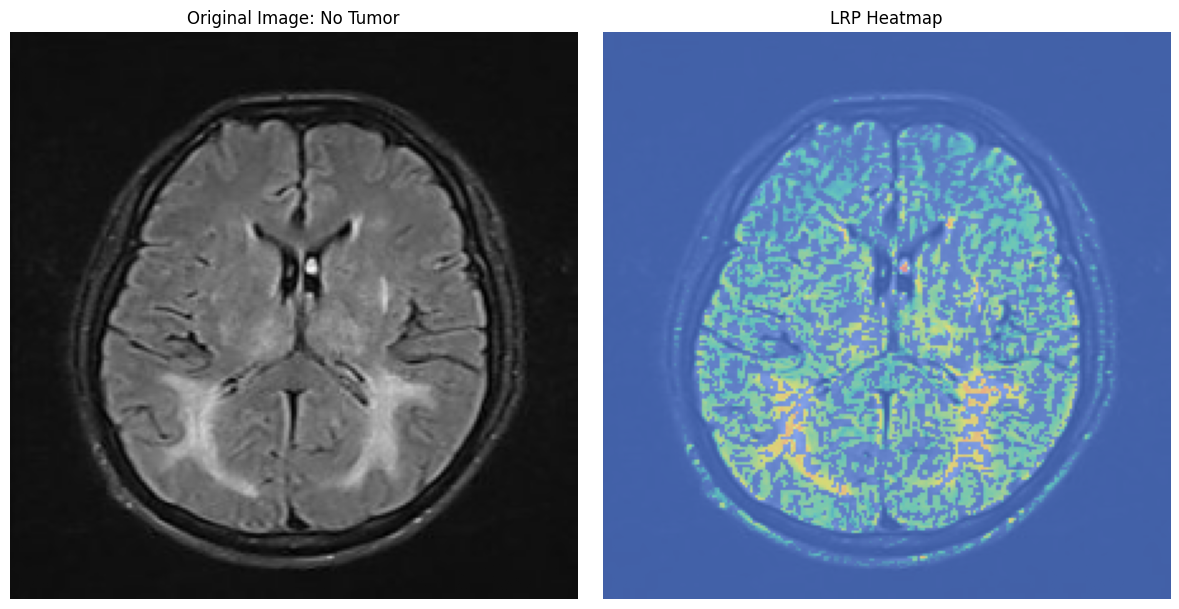

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Preprocessing function
IMAGE_SIZE = (224, 224)
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-noTr_0001.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, IMAGE_SIZE)
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image using correct preprocessing
preprocessed_image = preprocess_image(sample_image, None)[0]  # Preprocess using your defined method
prediction = final_model.predict(preprocessed_image)
predicted_class = np.argmax(prediction, axis=1)[0]

# Map predicted class index to actual class names
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
original_class_name = class_names[predicted_class]  # This will be the original class name

# Print the original image name (no predicted class)
print(f"Original Image Name: {image_name}")

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(preprocessed_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(preprocessed_image[0])
plt.title(f"Original Image: {original_class_name}")  # Display only the class name
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(preprocessed_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap")  # No class name here
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 2s 2s/step


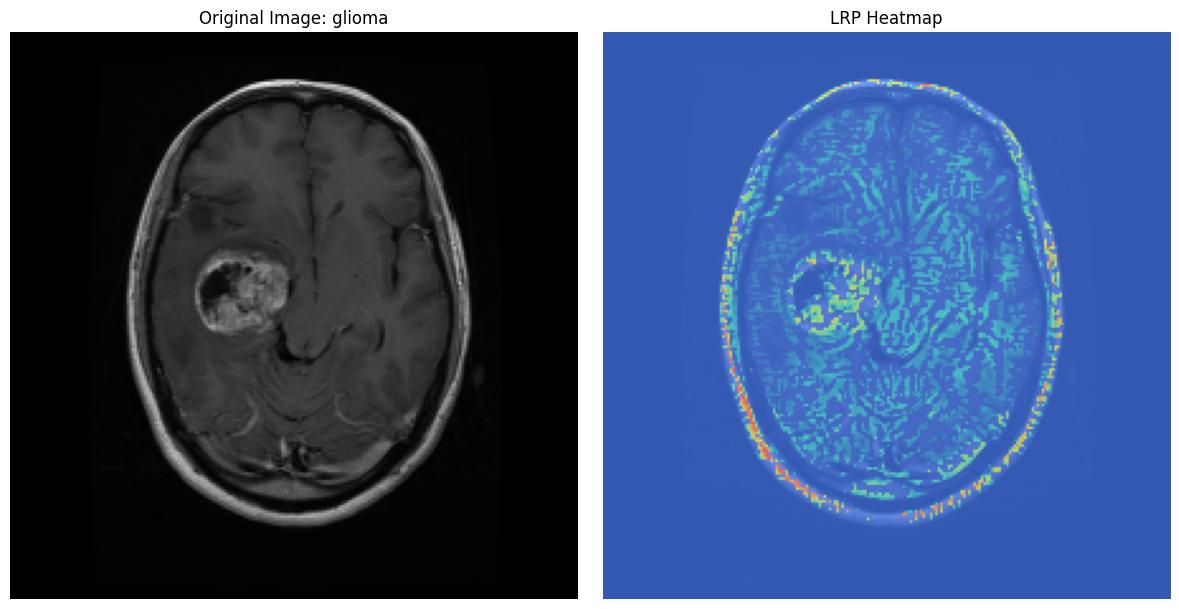

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Preprocessing function
IMAGE_SIZE = (224, 224)
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Function to extract the original class name from the image path
def extract_class_name(image_path):
    # Assuming the path structure is something like '/path/to/images/<ClassName>/image.jpg'
    # Split the path and get the class name from the folder
    class_name = os.path.basename(os.path.dirname(image_path))
    return class_name

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-gl_0028.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
original_class_name = extract_class_name(image_path)  # Extract the class name based on the image path

sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, IMAGE_SIZE)
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image using correct preprocessing
preprocessed_image = preprocess_image(sample_image, None)[0]  # Preprocess using your defined method
prediction = final_model.predict(preprocessed_image)

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(preprocessed_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(preprocessed_image[0])
plt.title(f"Original Image: {original_class_name}")  # Display the original class name
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(preprocessed_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.5)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap")  # No class name here
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 1s 888ms/step


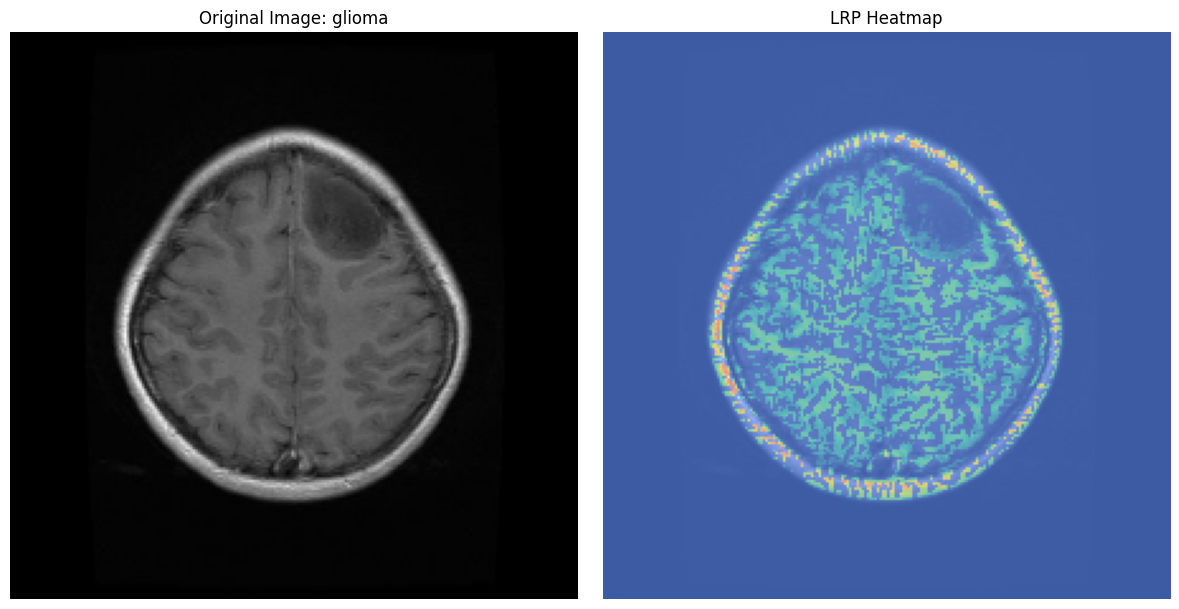

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Preprocessing function
IMAGE_SIZE = (224, 224)
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Function to extract the original class name from the image path
def extract_class_name(image_path):
    # Assuming the path structure is something like '/path/to/images/<ClassName>/image.jpg'
    # Split the path and get the class name from the folder
    class_name = os.path.basename(os.path.dirname(image_path))
    return class_name

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-glTr_0005.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
original_class_name = extract_class_name(image_path)  # Extract the class name based on the image path

sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, IMAGE_SIZE)
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image using correct preprocessing
preprocessed_image = preprocess_image(sample_image, None)[0]  # Preprocess using your defined method
prediction = final_model.predict(preprocessed_image)

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(preprocessed_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(preprocessed_image[0])
plt.title(f"Original Image: {original_class_name}")  # Display the original class name
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(preprocessed_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap")  # No class name here
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 1s 922ms/step


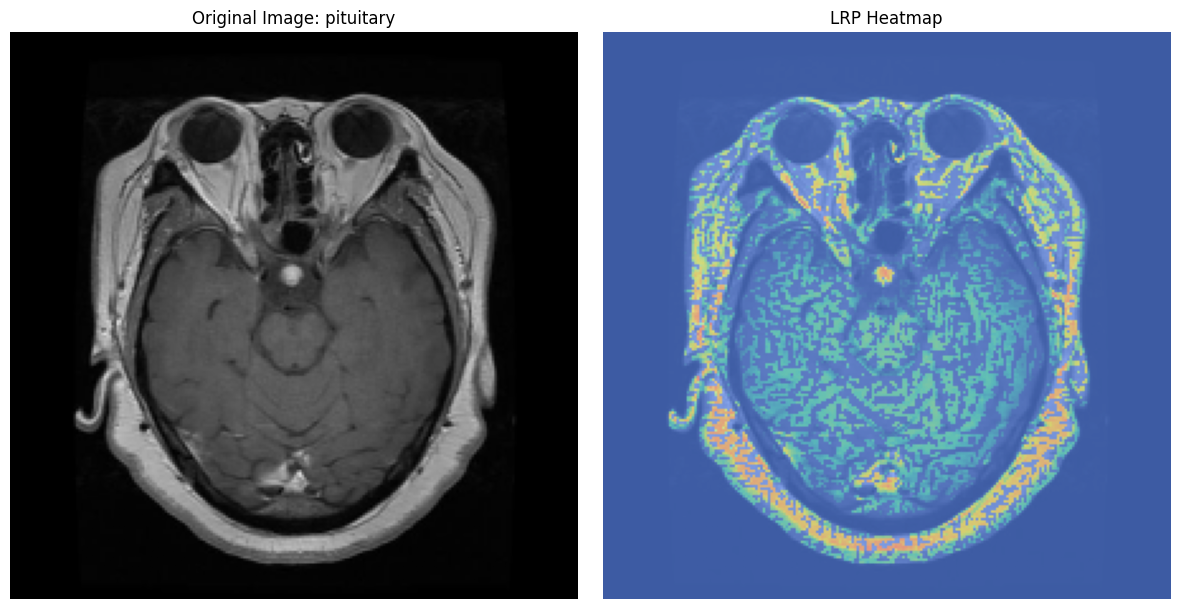

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Preprocessing function
IMAGE_SIZE = (224, 224)
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Function to extract the original class name from the image path
def extract_class_name(image_path):
    # Assuming the path structure is something like '/path/to/images/<ClassName>/image.jpg'
    # Split the path and get the class name from the folder
    class_name = os.path.basename(os.path.dirname(image_path))
    return class_name

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_0010.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
original_class_name = extract_class_name(image_path)  # Extract the class name based on the image path

sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, IMAGE_SIZE)
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image using correct preprocessing
preprocessed_image = preprocess_image(sample_image, None)[0]  # Preprocess using your defined method
prediction = final_model.predict(preprocessed_image)

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(preprocessed_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(preprocessed_image[0])
plt.title(f"Original Image: {original_class_name}")  # Display the original class name
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(preprocessed_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap")  # No class name here
plt.axis('off')

plt.tight_layout()
plt.show()


1/1 [==============================] - 1s 907ms/step


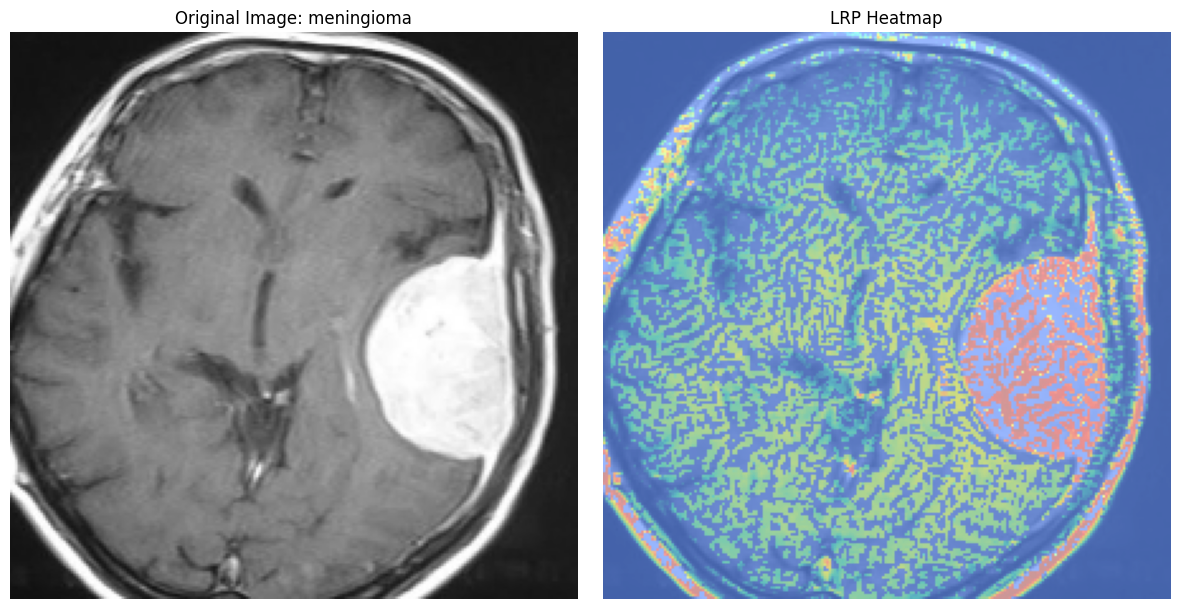

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Reshape, Layer, GlobalAveragePooling1D
import os

# Preprocessing function
IMAGE_SIZE = (224, 224)
def preprocess_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# Custom Layer for LRP (Layer-wise Relevance Propagation)
class LRPModifiedLayer(Layer):
    def __init__(self, model, epsilon=1e-7, **kwargs):
        super(LRPModifiedLayer, self).__init__(**kwargs)
        self.model = model
        self.epsilon = epsilon

    def call(self, inputs):
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            predictions = self.model(inputs)
            class_of_interest = tf.reduce_max(predictions, axis=1)
        
        grads = tape.gradient(class_of_interest, inputs)
        relevance = grads * inputs
        relevance = relevance / (tf.abs(grads) + self.epsilon)
        return relevance

# Function to extract the original class name from the image path
def extract_class_name(image_path):
    # Assuming the path structure is something like '/path/to/images/<ClassName>/image.jpg'
    # Split the path and get the class name from the folder
    class_name = os.path.basename(os.path.dirname(image_path))
    return class_name

# Load and preprocess the image
image_path = '/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0012.jpg'
image_name = os.path.basename(image_path)  # Extract the image name
original_class_name = extract_class_name(image_path)  # Extract the class name based on the image path

sample_image = plt.imread(image_path)
sample_image = tf.convert_to_tensor(sample_image, dtype=tf.float32)
sample_image = tf.image.resize(sample_image, IMAGE_SIZE)
sample_image = sample_image / 255.0
sample_image = tf.expand_dims(sample_image, axis=0)

# Define the combined VGG19 + LSTM model
def Combined_model():
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Load VGG19 base model (as feature extractor)
    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=input_layer)
    
    # Reshape the output of VGG19 to feed into LSTM
    x = base_model.output
    x = Reshape((49, 512))(x)
    
    # Apply LSTM layers
    x = LSTM(512, activation="relu", return_sequences=False)(x)
    
    # Apply global pooling or flattening layer after LSTM
    x = GlobalAveragePooling1D()(tf.expand_dims(x, axis=1))  # Expand dims for Global Pooling
    
    # Fully connected layers
    x = Dense(4096, activation='relu')(x)
    x = Dense(4096, activation='relu')(x)
    
    # Output layer for 4 classes (Glioma, Meningioma, No Tumor, Pituitary)
    output = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=input_layer, outputs=output)
    return model

# Create the VGG19 + LSTM model
final_model = Combined_model()

# Create the LRP model using the custom LRP layer
lrp_layer = LRPModifiedLayer(final_model)
lrp_model = Model(inputs=final_model.input, outputs=lrp_layer(final_model.input))

# Predict the class for the image using correct preprocessing
preprocessed_image = preprocess_image(sample_image, None)[0]  # Preprocess using your defined method
prediction = final_model.predict(preprocessed_image)

# Compute LRP relevance for the tumor region
lrp_result = lrp_model.predict(preprocessed_image)

# Post-process the LRP result
lrp_result = np.maximum(lrp_result, 0)  # Set negative relevance values to 0
lrp_result /= np.max(lrp_result)  # Normalize to [0, 1]
lrp_result = np.clip(lrp_result, 0.2, 1)  # Clip values to enhance focus

# Create visualization
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(preprocessed_image[0])
plt.title(f"Original Image: {original_class_name}")  # Display the original class name
plt.axis('off')

# LRP Heatmap
plt.subplot(1, 2, 2)
heatmap = plt.cm.jet(lrp_result[0, :, :, 0])  # Use the first 2D slice of LRP result
plt.imshow(preprocessed_image[0], alpha=0.6)  # Display the original image in the background
plt.imshow(heatmap[:, :, :3], alpha=0.4)  # Overlay the heatmap without the alpha channel
plt.title(f"LRP Heatmap")  # No class name here
plt.axis('off')

plt.tight_layout()
plt.show()
